esc-r makes a raw cell, just plain text (markdown and code are executed)

# Rocket Equation
At time $t_0$ to rocket starts to expel gas at a
_constant mass flow rate_ $R$ meassured in kg/s
and _exhaust velocity relative to the rocket_
$v_e$ in m/s.
$$
\frac{dv}{dt} = -\frac{F}{m(t)} = -\frac{Rv_e}{m(t)}
$$ {#eq-rocket-acc}
Integrating both sides of @eq-rocket-acc from 0
to $T$ we get

Open data in python: (Reading a Data File)

In [2]:
dataFile = open("data/pulse_data.csv")

create an empty list:

In [3]:
time = []
absorption = []

In [4]:
dataFile.readline() #discarding first line (header)
for line in dataFile.readlines():
    line = line.split(",")
    time.append(float(line[0]))
    absorption.append(float(line[1]))

Numpy is on the Charité server, for calculating things like matlab; matplotlib is another library, pyplot is a collection within

In [5]:
import numpy
from matplotlib import pyplot

Homework session 3 removed

In [7]:
x=time
y=absorption

Text(0.5, 0, 'time [s]')

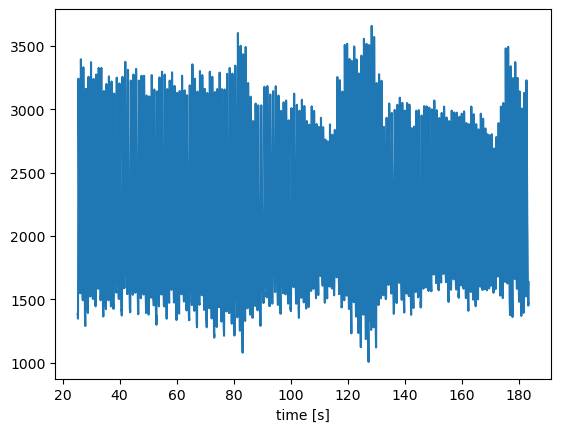

In [8]:
#| label: fig-dataset
#| fig-cap: "Measurements from an oxymetry sensor as a
#| function of time for 3 cycles"
pyplot.plot(time,absorption)
pyplot.xlabel("time [s]")

In [20]:
a=numpy.arange(10)+1

In [21]:
a.shape

(10,)

In [22]:
a.dtype

dtype('int64')

In [23]:
a.nbytes

80

In [24]:
b=numpy.array([[1,2,3],[4,5,6]])

In [25]:
b.shape

(2, 3)

In [27]:
b.T 

array([[1, 4],
       [2, 5],
       [3, 6]])

In [28]:
b.T @b

array([[17, 22, 27],
       [22, 29, 36],
       [27, 36, 45]])

In [29]:
a.T @a

np.int64(385)

In [30]:
a

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [31]:
numpy.max(a)

np.int64(10)

In [32]:
numpy.argmax(a)

np.int64(9)

In [9]:
absorption = numpy.array(absorption)
time = numpy.array(time)

In [10]:
w=50

In [11]:
subset = absorption #you can choose what part of the data to analyze [:1000]

In [57]:
peaks = []
for i in range(len(subset)):
    start = max(i-w,0)
    end = min(i+w, len(subset))
    window = subset[start:end]
    max_pos = numpy.argmax(window) + start
    if i == max_pos:
        peaks.append(i)
print(peaks)

[96, 438, 774, 1142, 1502, 1851, 2211, 2578, 2929, 3291, 3651, 4003, 4356, 4724, 5092, 5452, 5828, 6252, 6647, 7022, 7414, 7787, 8159, 8548, 8919, 9272, 9626, 9992, 10344, 10703, 11076, 11429, 11781, 12153, 12514, 12855, 13183, 13531, 13891, 14247, 14587, 14927, 15286, 15662, 16034, 16388, 16746, 17087, 17413, 17751, 18109, 18465, 18812, 19167, 19505, 19842, 20173, 20535, 20880, 21246, 21628, 22024, 22393, 22767, 23144, 23483, 23822, 24177, 24527, 24872, 25237, 25664, 26106, 26516, 26920, 27319, 27693, 28070, 28439, 28787, 29136, 29488, 29888, 30262, 30639, 31005, 31345, 31686, 32034, 32381, 32719, 33052, 33385, 33712, 34012, 34312, 34632, 34953, 35275, 35601, 35948, 36305, 36660, 37008, 37344, 37671, 38002, 38340, 38662, 38983, 39317, 39672, 40020, 40376, 40745, 41102, 41448, 41797, 42140, 42477, 42822, 43191, 43556, 43921, 44323, 44698, 45040, 45387, 45736, 46058, 46378, 46696, 47019, 47343, 47700, 48084, 48440, 48791, 49161, 49524, 49863, 50206, 50556, 50895, 51231, 51576, 51940, 52

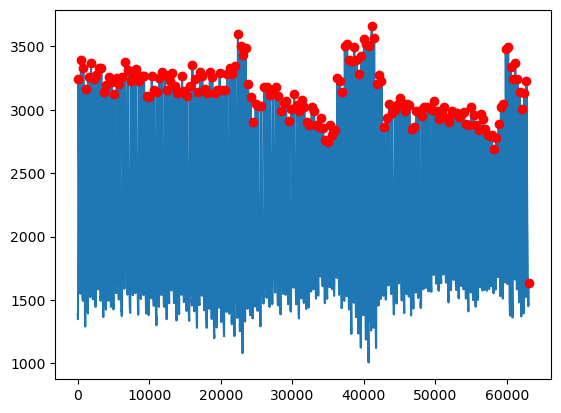

In [58]:
pyplot.plot(subset)
pyplot.plot(peaks,subset[peaks], "ro")

In [41]:
test = numpy.arange(20)

In [42]:
s = test[5:10] #showing element position 5 to 9

In [43]:
s

array([5, 6, 7, 8, 9])

In [44]:
test

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [59]:
time_peaks = time[peaks]

In [60]:
delta_t = time_peaks[1:]- time_peaks[:-1]

In [61]:
hr = 60 / delta_t

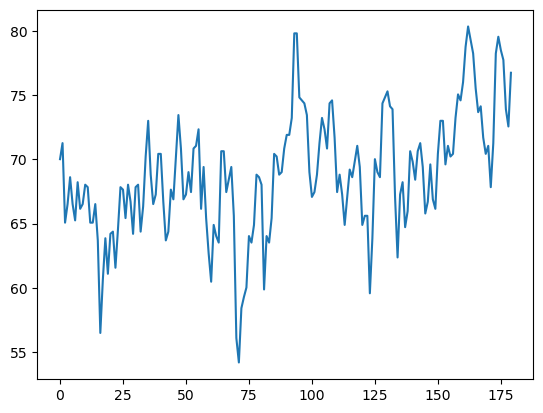

In [62]:
pyplot.plot(hr)

Homework session 5: use pandas and find peaks to find the peaks for calculating the hear rate

In [20]:
subset = absorption[:2000]

In [21]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(subset, height=0.5, distance=50)

returns two things:
peaks → indices of the peaks, properties → a dictionary with extra info (like heights, widths, etc.)
peaks, _ = find_peaks(signal)
The comma , is just unpacking two return values, the _ is a throwaway variable

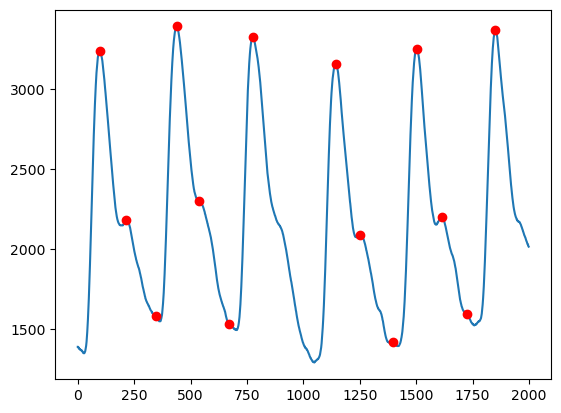

In [22]:
pyplot.plot(subset)
pyplot.plot(peaks,subset[peaks], "ro")

Adjusting height

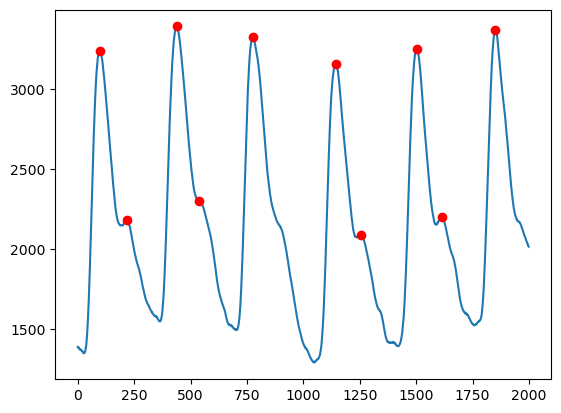

In [23]:
peaks, _ = find_peaks(subset, height=2000, distance=50)
pyplot.plot(subset)
pyplot.plot(peaks,subset[peaks], "ro")

Adjusting distance

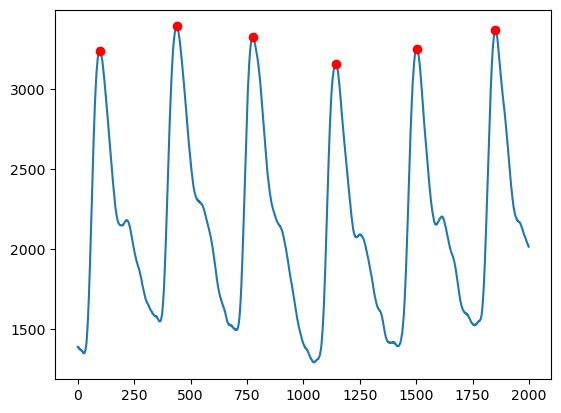

In [24]:
peaks, _ = find_peaks(subset, height=0.5, distance=200)
pyplot.plot(subset)
pyplot.plot(peaks,subset[peaks], "ro")